# ____Section 1____ 

## Section 1: Load & Validate Data
**Dataset**: CICIDS 2017
**Objective**: Load, merge, and validate raw network data.

# Data Collection and Overview

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1/1 Importation and download dataset
Purpose : Define the paths where data is read from and where results are saved.

In [2]:
DATA_PATH    = '/kaggle/input/datasets/yashpotdarpy/cicids-2017'
OUTPUT_PATH  = '/kaggle/working/'

print('Imports is OKay ! ')
print(f'Dossier data    : {DATA_PATH}')#verifaction 
print(f'Dossier output  : {OUTPUT_PATH}')

Imports is OKay ! 
Dossier data    : /kaggle/input/datasets/yashpotdarpy/cicids-2017
Dossier output  : /kaggle/working/


##  1/2 Exploring the dataset files

The dataset is composed of 8 files. Each file contains attacks detected in 5 days.

In [3]:
files = sorted(glob.glob(os.path.join(DATA_PATH, '*.csv')))

print(f' {len(files)} files founded ! :\n')
total_size = 0
for f in files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    total_size += size_mb
    print(f'   [{size_mb:6.1f} MB]  {os.path.basename(f)}')

print(f'\n   Total : {total_size:.1f} MB')

 8 files founded ! :

   [  73.6 MB]  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
   [  73.3 MB]  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
   [  55.6 MB]  Friday-WorkingHours-Morning.pcap_ISCX.csv
   [ 168.7 MB]  Monday-WorkingHours.pcap_ISCX.csv
   [  79.3 MB]  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
   [  49.6 MB]  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
   [ 128.8 MB]  Tuesday-WorkingHours.pcap_ISCX.csv
   [ 214.7 MB]  Wednesday-workingHours.pcap_ISCX.csv

   Total : 843.7 MB


## 1/3 Checking the dataset columns and it's consistency between files
Before merging 8 files into one DataFrame, we must verify that all files have exactly the same columns. If one file has a different column name or a missing column, the merge will fail or produce wrong results.

In [4]:
# Read only the header of each file (fast)
print('Verifying columns per file:')

columns_per_file = {}

for f in files:
    df_head = pd.read_csv(f, nrows=0)
    df_head.columns = df_head.columns.str.strip()  # remove spaces
    columns_per_file[os.path.basename(f)] = set(df_head.columns)
    print(f'   {os.path.basename(f)[:55]:<55} → {len(df_head.columns)} columns')

# Check if all files have identical columns
all_columns = list(columns_per_file.values())
common_columns = set.intersection(*all_columns)
union_columns = set.union(*all_columns)

print(f'\n Common columns across all files: {len(common_columns)}')

if len(common_columns) != len(union_columns):
    diff = union_columns - common_columns
    print(f' Columns missing in some files: {diff}')
else:
    print('All files have exactly the same columns, so we can merge it')

Verifying columns per file:
   Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv        → 79 columns
   Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv    → 79 columns
   Friday-WorkingHours-Morning.pcap_ISCX.csv               → 79 columns
   Monday-WorkingHours.pcap_ISCX.csv                       → 79 columns
   Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX → 79 columns
   Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  → 79 columns
   Tuesday-WorkingHours.pcap_ISCX.csv                      → 79 columns
   Wednesday-workingHours.pcap_ISCX.csv                    → 79 columns

 Common columns across all files: 79
All files have exactly the same columns, so we can merge it


## 1/4 Chargement et fusion des fichiers (DataLoader)


In [5]:
# ── DataLoader Class (matches the Class Diagram)
class DataLoader:
    def __init__(self, data_source: str):
        self._data_source = data_source  # data_source: String

    def load_data(self) -> pd.DataFrame:
        """Loads and merges all CSV files from the folder."""
        files = sorted(glob.glob(os.path.join(self._data_source, '*.csv')))
        
        if not files:
            raise FileNotFoundError(f'No CSV files found in: {self._data_source}')

        dataframes = []

        for f in files:
            filename = os.path.basename(f)
            df_temp = pd.read_csv(f, encoding='utf-8', low_memory=False)
            df_temp.columns = df_temp.columns.str.strip()
            df_temp['source_file'] = filename

            dataframes.append(df_temp)

            print(f'   ✓ {filename:<55} {df_temp.shape[0]:>8,} rows')

        df = pd.concat(dataframes, ignore_index=True)

        print(f'\n Merge completed: {df.shape[0]:,} rows × {df.shape[1]} columns')
        return df

    def validate_data(self, df: pd.DataFrame) -> bool:
        """Validates structure and completeness. Returns True if valid."""
        print('\n Validating data...')
        errors = []

        if df is None or df.empty:
            errors.append('Empty dataset')

        if 'Label' not in df.columns:
            errors.append('Missing "Label" column')

        missing_rate = df.isnull().mean().max()
        if missing_rate > 0.5:
            errors.append(f'Too many missing values: {missing_rate:.1%}')

        if 'Label' in df.columns and df['Label'].nunique() < 2:
            errors.append('Less than 2 classes in "Label"')

        if errors:
            for e in errors:
                print(f'  {e}')
            return False

        print('   ✔ Structure OK')
        print(f'  ✔ {df["Label"].nunique()} classes detected')
        print(f'  ✔ Missing values rate: {missing_rate:.2%}')

        return True


# ── Execution
print('Loading files...\n')

loader = DataLoader(DATA_PATH)
df_raw = loader.load_data()

Loading files...

   ✓ Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv         225,745 rows
   ✓ Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv     286,467 rows
   ✓ Friday-WorkingHours-Morning.pcap_ISCX.csv                191,033 rows
   ✓ Monday-WorkingHours.pcap_ISCX.csv                        529,918 rows
   ✓ Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  288,602 rows
   ✓ Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv   170,366 rows
   ✓ Tuesday-WorkingHours.pcap_ISCX.csv                       445,909 rows
   ✓ Wednesday-workingHours.pcap_ISCX.csv                     692,703 rows

 Merge completed: 2,830,743 rows × 80 columns


## 1/5 — Data validation

In [6]:
# Validation (Activity Diagram: "Validate data → Data valid?")
is_valid = loader.validate_data(df_raw)

if not is_valid:
    raise Exception('Invalid data — fix errors before continuing')

print('\n Proceeding to Section 2 (ETL) is allowed ')


 Validating data...
   ✔ Structure OK
  ✔ 15 classes detected
  ✔ Missing values rate: 0.05%

 Proceeding to Section 2 (ETL) is allowed 


In [9]:
df_raw.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


In [10]:
df_raw.tail()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
2830738,53,32215,4,2,112,152,28,28,28.0,0.00000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Wednesday-workingHours.pcap_ISCX.csv
2830739,53,324,2,2,84,362,42,42,42.0,0.00000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Wednesday-workingHours.pcap_ISCX.csv
2830740,58030,82,2,1,31,6,31,0,15.5,21.92031,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Wednesday-workingHours.pcap_ISCX.csv
2830741,53,1048635,6,2,192,256,32,32,32.0,0.00000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Wednesday-workingHours.pcap_ISCX.csv
2830742,53,94939,4,2,188,226,47,47,47.0,0.00000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Wednesday-workingHours.pcap_ISCX.csv


In [11]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 80 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

# EDA — Exploratory Data Analysis

**E — Exploratory**

In [13]:
# ── E : Exploratory — General structure
print('═' * 55)
print('   E — EXPLORATORY : General Overview')
print('═' * 55)
print(f'  Shape        : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'  Memory       : {df_raw.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print(f'  Column types :')
for dtype, count in df_raw.dtypes.value_counts().items():
    print(f'     {str(dtype):<12} → {count} columns')
print('═' * 55)

═══════════════════════════════════════════════════════
   E — EXPLORATORY : General Overview
═══════════════════════════════════════════════════════
  Shape        : 2,830,743 rows × 80 columns
  Memory       : 2078.1 MB
  Column types :
     int64        → 54 columns
     float64      → 24 columns
     object       → 2 columns
═══════════════════════════════════════════════════════


In [14]:
df_raw.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


**D — Data**

In [15]:
# ── D : Data — Content analysis
print('═' * 55)
print('   D — DATA : Content Analysis')
print('═' * 55)

# Class distribution
label_counts = df_raw['Label'].value_counts()
print('Class distribution:\n')
print(label_counts.to_string())
print(f'\n→ BENIGN : {label_counts.get("BENIGN", 0):,}')
print(f'→ ATTACK : {label_counts[label_counts.index != "BENIGN"].sum():,}')

═══════════════════════════════════════════════════════
   D — DATA : Content Analysis
═══════════════════════════════════════════════════════
Class distribution:

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11

→ BENIGN : 2,273,097
→ ATTACK : 557,646


In [18]:
# Missing values
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False).head(15)
print('\nMissing values :')
if missing.empty:
    print(' No missing values detected')
else:
    print(missing.to_string())


Missing values :
Flow Bytes/s    1358


In [19]:
print('=' * 60)
print('   DEEP NaN EXPLORATION')
print('=' * 60)

# 1. Which columns have NaN
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'\nColumns with NaN : {len(missing)}')
print(missing.to_string())

# 2. Percentage of NaN
print(f'\nNaN percentage per column :')
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
print(missing_pct.to_string())

# 3. Where exactly are the NaN rows
print(f'\nRows with NaN - first 5 examples :')
nan_rows = df_raw[df_raw['Flow Bytes/s'].isnull()]
print(f'Total NaN rows : {len(nan_rows)}')
print(nan_rows[['Destination Port', 'Flow Duration', 
                 'Flow Bytes/s', 'Flow Packets/s', 'Label']].head())

# 4. What labels have NaN
print(f'\nLabel distribution in NaN rows :')
print(nan_rows['Label'].value_counts().to_string())

# 5. Flow Duration = 0 in NaN rows
zero_duration = df_raw[df_raw['Flow Duration'] == 0]
print(f'\nRows with Flow Duration = 0 : {len(zero_duration):,}')
print(f'NaN in these rows : {zero_duration["Flow Bytes/s"].isnull().sum():,}')

   DEEP NaN EXPLORATION

Columns with NaN : 1
Flow Bytes/s    1358

NaN percentage per column :
Flow Bytes/s    0.047973

Rows with NaN - first 5 examples :
Total NaN rows : 1358
        Destination Port  Flow Duration  Flow Bytes/s  Flow Packets/s   Label
6796               36812              0           NaN             inf  BENIGN
14739              53581              0           NaN             inf  BENIGN
15047                 80              0           NaN             inf  BENIGN
209728             18467              0           NaN             inf  BENIGN
238569             13370              0           NaN             inf  BENIGN

Label distribution in NaN rows :
Label
DoS Hulk    949
BENIGN      409

Rows with Flow Duration = 0 : 2,867
NaN in these rows : 1,358


In [20]:
print('=' * 60)
print('   DEEP INFINITE VALUES EXPLORATION')
print('=' * 60)

import numpy as np

# 1. Which columns have inf
inf_per_col = np.isinf(df_raw.select_dtypes(include='number')).sum()
inf_per_col = inf_per_col[inf_per_col > 0].sort_values(ascending=False)
print(f'\nColumns with infinite values :')
print(inf_per_col.to_string())

# 2. Positive vs Negative infinity
for col in inf_per_col.index:
    pos_inf = (df_raw[col] == np.inf).sum()
    neg_inf = (df_raw[col] == -np.inf).sum()
    print(f'\n{col} :')
    print(f'   +inf : {pos_inf:,}')
    print(f'   -inf : {neg_inf:,}')

# 3. Examples of inf rows
print(f'\nExamples of rows with inf in Flow Bytes/s :')
inf_rows = df_raw[df_raw['Flow Bytes/s'] == np.inf]
print(f'Total inf rows : {len(inf_rows):,}')
print(inf_rows[['Destination Port', 'Flow Duration',
                 'Total Fwd Packets', 'Flow Bytes/s',
                 'Flow Packets/s', 'Label']].head(10))

# 4. Confirm Flow Duration = 0 causes inf
print(f'\nFlow Duration = 0 in inf rows :')
print(f'   Min Duration in inf rows : {inf_rows["Flow Duration"].min()}')
print(f'   Max Duration in inf rows : {inf_rows["Flow Duration"].max()}')
print(f'   Mean Duration in inf rows : {inf_rows["Flow Duration"].mean():.2f}')

# 5. Labels in inf rows
print(f'\nLabel distribution in inf rows :')
print(inf_rows['Label'].value_counts().to_string())

   DEEP INFINITE VALUES EXPLORATION

Columns with infinite values :
Flow Packets/s    2867
Flow Bytes/s      1509

Flow Packets/s :
   +inf : 2,867
   -inf : 0

Flow Bytes/s :
   +inf : 1,509
   -inf : 0

Examples of rows with inf in Flow Bytes/s :
Total inf rows : 1,509
       Destination Port  Flow Duration  Total Fwd Packets  Flow Bytes/s  \
65                55043              0                  2           inf   
1767              60018              0                  2           inf   
1890                 80              0                  1           inf   
3375                443              0                  1           inf   
8057              35382              0                  1           inf   
8405              55421              0                  2           inf   
13313              9242              0                  2           inf   
13716               389              0                  2           inf   
18253             57919              0               

In [21]:
print('=' * 60)
print('   DEEP DUPLICATES EXPLORATION')
print('=' * 60)

# 1. Total duplicates
dup_mask = df_raw.duplicated(keep=False)
all_dups = df_raw[dup_mask]
first_dups = df_raw[df_raw.duplicated(keep='first')]

print(f'\nTotal rows involved in duplication : {len(all_dups):,}')
print(f'Rows to remove (keep first)        : {len(first_dups):,}')
print(f'Percentage of dataset              : {len(first_dups)/len(df_raw)*100:.2f}%')

# 2. Duplicates per file
print(f'\nDuplicates per source file :')
dup_by_file = first_dups['source_file'].value_counts()
print(dup_by_file.to_string())

# 3. Duplicates per label
print(f'\nDuplicates per label :')
dup_by_label = first_dups['Label'].value_counts()
print(dup_by_label.to_string())

# 4. Example of duplicate rows
print(f'\nExample of duplicate rows (first 3 pairs) :')
dup_example = df_raw[df_raw.duplicated(keep=False)].sort_values(
    by=list(df_raw.columns[:5])).head(6)
print(dup_example[['Destination Port', 'Flow Duration',
                    'Total Fwd Packets', 'Label', 'source_file']].to_string())

# 5. How many times are rows duplicated
print(f'\nHow many times rows are repeated :')
dup_counts = df_raw.groupby(
    list(df_raw.select_dtypes(include='number').columns[:10])
).size().reset_index(name='count')
dup_counts = dup_counts[dup_counts['count'] > 1]
print(f'   2x duplicated : {(dup_counts["count"] == 2).sum():,} groups')
print(f'   3x duplicated : {(dup_counts["count"] == 3).sum():,} groups')
print(f'   4x+ duplicated: {(dup_counts["count"] >= 4).sum():,} groups')

   DEEP DUPLICATES EXPLORATION

Total rows involved in duplication : 337,556
Rows to remove (keep first)        : 256,479
Percentage of dataset              : 9.06%

Duplicates per source file :
source_file
Wednesday-workingHours.pcap_ISCX.csv                           81909
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv           72353
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv    35630
Monday-WorkingHours.pcap_ISCX.csv                              26935
Tuesday-WorkingHours.pcap_ISCX.csv                             24065
Friday-WorkingHours-Morning.pcap_ISCX.csv                       6888
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv          6066
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv                2633

Duplicates per label :
Label
BENIGN                      124711
PortScan                     68111
DoS Hulk                     58224
SSH-Patator                   2678
FTP-Patator                   2005
DoS slowloris                  411
D

In [23]:
print('=' * 60)
print('   DEEP OUTLIERS EXPLORATION')
print('=' * 60)

# Key features to check for outliers
features = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Fwd Packet Length Max',
    'Fwd Packet Length Mean',
    'SYN Flag Count',
    'ACK Flag Count'
]

print(f'\nOutlier analysis using IQR method :')
print(f'{"Feature":<35} {"Min":>12} {"Max":>15} {"Mean":>12} {"Outliers":>10} {"Pct":>8}')
print('-' * 95)

outlier_summary = {}
for col in features:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_raw[(df_raw[col] < lower) | (df_raw[col] > upper)]
    pct = len(outliers) / len(df_raw) * 100
    outlier_summary[col] = len(outliers)
    print(f'{col:<35} {df_raw[col].min():>12.2f} {df_raw[col].max():>15.2f} '
          f'{df_raw[col].mean():>12.2f} {len(outliers):>10,} {pct:>7.2f}%')

   DEEP OUTLIERS EXPLORATION

Outlier analysis using IQR method :
Feature                                      Min             Max         Mean   Outliers      Pct
-----------------------------------------------------------------------------------------------
Flow Duration                             -13.00    119999998.00  14785663.93    532,586   18.81%
Total Fwd Packets                           1.00       219759.00         9.36    332,693   11.75%
Total Backward Packets                      0.00       291922.00        10.39    308,291   10.89%
Flow Bytes/s                        -261000000.00             inf          inf    532,458   18.81%
Flow Packets/s                       -2000000.00             inf          inf    306,567   10.83%
Fwd Packet Length Max                       0.00        24820.00       207.60    664,214   23.46%
Fwd Packet Length Mean                      0.00         5940.86        58.20    188,020    6.64%
SYN Flag Count                              0.00     

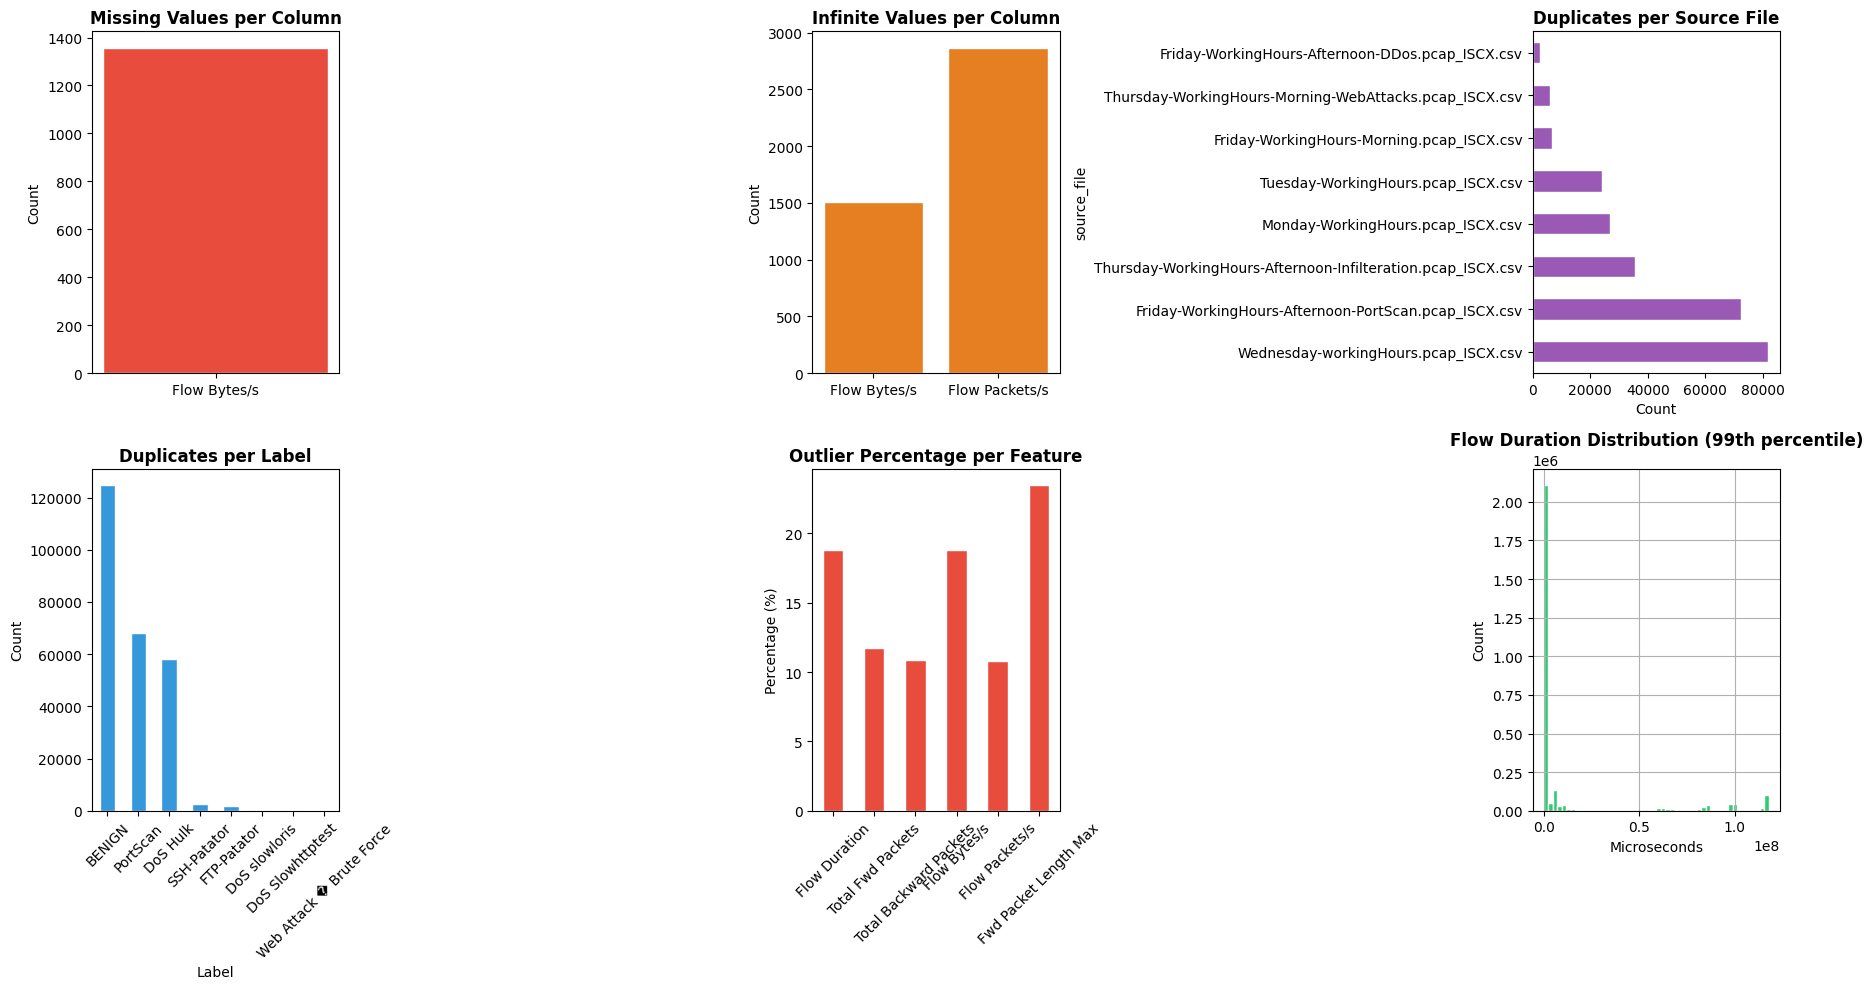

Graph saved : deep_exploration.png


In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1 : NaN distribution
missing_data = pd.DataFrame({
    'Column': ['Flow Bytes/s'],
    'NaN Count': [1358]
})
axes[0,0].bar(missing_data['Column'], missing_data['NaN Count'],
              color='#e74c3c', edgecolor='white')
axes[0,0].set_title('Missing Values per Column', fontweight='bold')
axes[0,0].set_ylabel('Count')

# Plot 2 : Inf distribution
inf_data = pd.DataFrame({
    'Column': ['Flow Bytes/s', 'Flow Packets/s'],
    'Inf Count': [inf_per_col.get('Flow Bytes/s', 0),
                  inf_per_col.get('Flow Packets/s', 0)]
})
axes[0,1].bar(inf_data['Column'], inf_data['Inf Count'],
              color='#e67e22', edgecolor='white')
axes[0,1].set_title('Infinite Values per Column', fontweight='bold')
axes[0,1].set_ylabel('Count')

# Plot 3 : Duplicates per file
dup_by_file.plot(kind='barh', ax=axes[0,2], color='#9b59b6', edgecolor='white')
axes[0,2].set_title('Duplicates per Source File', fontweight='bold')
axes[0,2].set_xlabel('Count')

# Plot 4 : Duplicates per label
dup_by_label.head(8).plot(kind='bar', ax=axes[1,0], color='#3498db', edgecolor='white')
axes[1,0].set_title('Duplicates per Label', fontweight='bold')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=45)

# Plot 5 : Outliers percentage per feature
outlier_pcts = {}
for col in features[:6]:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_raw[(df_raw[col] < Q1-1.5*IQR) | (df_raw[col] > Q3+1.5*IQR)]
    outlier_pcts[col] = len(outliers)/len(df_raw)*100

pd.Series(outlier_pcts).plot(kind='bar', ax=axes[1,1],
                              color='#e74c3c', edgecolor='white')
axes[1,1].set_title('Outlier Percentage per Feature', fontweight='bold')
axes[1,1].set_ylabel('Percentage (%)')
axes[1,1].tick_params(axis='x', rotation=45)

# Plot 6 : Flow Duration distribution
df_raw['Flow Duration'].clip(upper=df_raw['Flow Duration'].quantile(0.99)).hist(
    ax=axes[1,2], bins=50, color='#2ecc71', edgecolor='white')
axes[1,2].set_title('Flow Duration Distribution (99th percentile)', fontweight='bold')
axes[1,2].set_xlabel('Microseconds')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'deep_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graph saved : deep_exploration.png')

**Cellule A — Analysis**

═══════════════════════════════════════════════════════
   A — ANALYSIS : Visualization
═══════════════════════════════════════════════════════


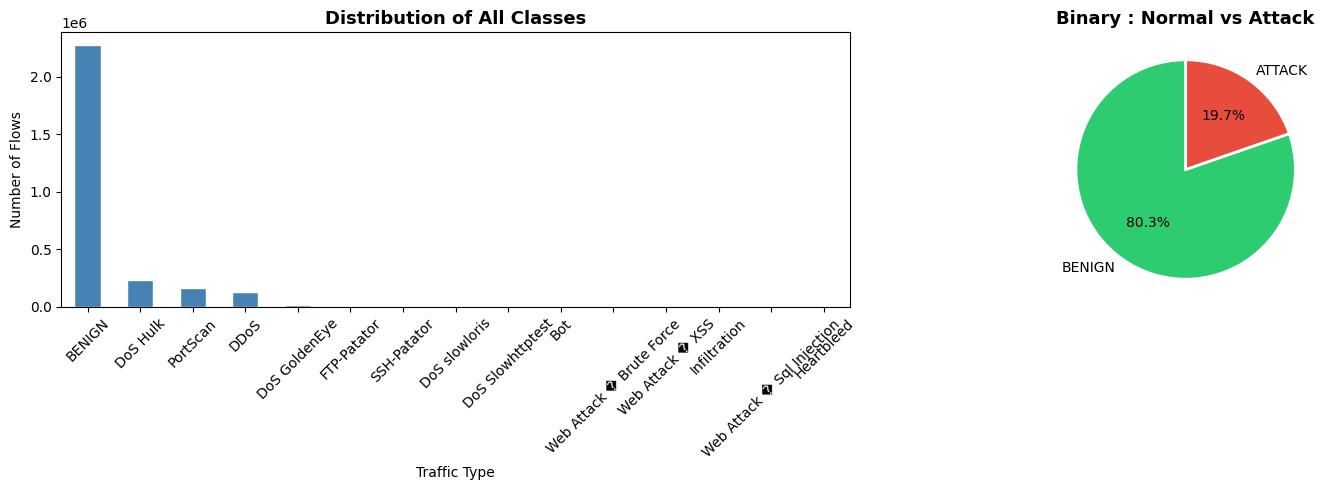

Graph saved as: class_distribution.png


In [25]:
# ── A : Analysis — Visual analysis
print('═' * 55)
print('   A — ANALYSIS : Visualization')
print('═' * 55)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 : all classes
label_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of All Classes', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Traffic Type')
axes[0].set_ylabel('Number of Flows')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2 : binary BENIGN vs ATTACK
binary = pd.Series({
    'BENIGN': label_counts.get('BENIGN', 0),
    'ATTACK': label_counts[label_counts.index != 'BENIGN'].sum()
})
colors = ['#2ecc71', '#e74c3c']
binary.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Binary : Normal vs Attack', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graph saved as: class_distribution.png')

# ── Complete Diagnostic — summary of all issues

In [26]:
print("=" * 55)
print("   COMPLETE DATASET DIAGNOSTIC")
print("=" * 55)
print(f"\nShape          : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Infinite values: {np.isinf(df_raw.select_dtypes(include='number')).sum().sum():,}")
print(f"Missing values : {df_raw.isnull().sum().sum():,}")
print(f"Duplicate rows : {df_raw.duplicated().sum():,}")
print(f"Constant cols  : {sum(df_raw[c].nunique() <= 1 for c in df_raw.columns)}")

benign = (df_raw['Label'] == 'BENIGN').sum()
attack = (df_raw['Label'] != 'BENIGN').sum()
ratio  = benign / attack
print(f"\nBENIGN/ATTACK ratio: {ratio:.1f}x")
print("Acceptable imbalance" if ratio <= 5 else "Highly imbalanced")
print("=" * 55)
print("Result → issues to fix in ETL")
print("=" * 55)

   COMPLETE DATASET DIAGNOSTIC

Shape          : 2,830,743 rows × 80 columns
Infinite values: 4,376
Missing values : 1,358
Duplicate rows : 256,479
Constant cols  : 8

BENIGN/ATTACK ratio: 4.1x
Acceptable imbalance
Result → issues to fix in ETL


In [15]:
# Check which file contributes most to missing values
print('Missing values per source file :')
missing_by_file = df_raw[df_raw['Flow Bytes/s'].isnull()]['source_file'].value_counts()
print(missing_by_file.to_string())

Missing values per source file :
source_file
Wednesday-workingHours.pcap_ISCX.csv                           1008
Tuesday-WorkingHours.pcap_ISCX.csv                              201
Monday-WorkingHours.pcap_ISCX.csv                                64
Friday-WorkingHours-Morning.pcap_ISCX.csv                        28
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv           20
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv      18
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv             15
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv                  4


# Save the merged raw dataset for next Step (ETL)

Purpose : Save the merged raw dataset so Section 2 (ETL) can load it directly.

In [30]:
save_path = OUTPUT_PATH + 'df_raw.csv'
df_raw.to_csv(save_path, index=False)

print(f' Raw dataset saved at: {save_path}')
print(f'   → {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print('\n Section 1 completed -----> Section2')

 Raw dataset saved at: /kaggle/working/df_raw.csv
   → 2,830,743 rows × 80 columns

 Section 1 completed -----> Section2
